# LSTM Model
This notebook trains an LSTM neural network to predict the winner of the SC2 match at each 10 second event window in the games event stream.

## Setup

In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss, roc_auc_score

from keras.regularizers import l2
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

# Load Data

In [202]:
data = pd.read_pickle("../../data/Terran_vs_Zerg.pkl")
# convert target to 0, 1
data["winner"] = data["winner"] - 1

NON_FEATURES = [
    "filehash",
    "winner",
    "player_1_race",
    "player_2_race",
]

FEATURES = [col for col in data.columns if col not in NON_FEATURES]

TARGET = "winner"

In [203]:
FEATURES = FEATURES[:33]

In [204]:
data[TARGET].mean()

np.float64(0.4727267841788478)

In [205]:
data.groupby("filehash")[TARGET].mean().value_counts()

winner
0.0    163
1.0    139
Name: count, dtype: int64

In [206]:
print(f"Number of unique games: {data['filehash'].nunique()}")
print(f"Number of features: {len(FEATURES)}")

Number of unique games: 302
Number of features: 95


In [207]:
for feature in FEATURES:
    data[feature] = data[feature].astype(float)

In [208]:
train_data, test_data = train_test_split(data, "filehash", 0.2)

scaler = StandardScaler()
scaler.fit(train_data[FEATURES])

,copy,True
,with_mean,True
,with_std,True


In [209]:
train_data_scaled = train_data.copy()
test_data_scaled = test_data.copy()

In [210]:
train_data_scaled.loc[:, FEATURES] = scaler.transform(train_data_scaled[FEATURES])
test_data_scaled.loc[:, FEATURES] = scaler.transform(test_data_scaled[FEATURES])

In [211]:

def create_training_sample(data: pd.DataFrame, unique_id: str, features: list[str], target: str) -> tuple[np.ndarray, np.ndarray]:
    groups = data.groupby(unique_id)
    n_examples = data[unique_id].nunique()
    n_timesteps = groups[target].count().max()
    print(f"Maximum game length: {n_timesteps}")

    X_sequences = []
    y_sequences = []

    for group in groups:
        X_data = group[1][features].values
        y_data = [group[1][target].max()] * n_timesteps
        X_sequences.append(X_data)
        y_sequences.append(y_data)
    X_sequences = sequence.pad_sequences(X_sequences, dtype=float)
    y_sequences = np.array(y_sequences).reshape(n_examples, n_timesteps, 1)


    print(X_sequences.shape, y_sequences.shape)
    return X_sequences, y_sequences


train_X, train_y = create_training_sample(train_data_scaled, "filehash", FEATURES, "winner")
test_X, test_y = create_training_sample(test_data_scaled, "filehash", FEATURES, "winner")

Maximum game length: 340
(250, 340, 95) (250, 340, 1)
Maximum game length: 239
(52, 239, 95) (52, 239, 1)


In [212]:
class Sc2LSTM:
    """LSTM model for predicting sc2 game outcomes from time series data."""

    def __init__(
        self,
        lstm_units: int = 64,
        dropout_rate: float = 0.3,
        learning_rate: float = 0.001,
    ):
        """Initialize the LSTM model.

        Args:
            lstm_units: Number of LSTM units
            dropout_rate: Dropout rate for regularization
            learning_rate: Learning rate for optimization

        """
        self.lstm_units = lstm_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.model = None
        self.scaler = StandardScaler()
        self.history = None

    def build_model(self, sequence_length: int, n_features: int = 2) -> Model:
        """Build the LSTM model architecture.

        Args:
            sequence_length: Length of input sequences (minutes in game)
            n_features: Number of features (possession_pct, tackles)

        Returns:
            Compiled Keras model

        """
        # Input layer

        # LSTM layers with return_sequences=True for many-to-many prediction
        lstm_out = LSTM(
            units=self.lstm_units,
            return_sequences=True,
            dropout=self.dropout_rate,
            recurrent_dropout=self.dropout_rate,
            name="lstm_layer",
            kernel_regularizer=l2(0.01),
            recurrent_regularizer=l2(0.01),
            bias_regularizer=l2(0.01),
        )

        # Additional LSTM layer for more complex patterns
        lstm_out_two = LSTM(
            units=self.lstm_units // 2,
            return_sequences=True,
            dropout=self.dropout_rate,
            recurrent_dropout=self.dropout_rate,
            name="lstm_layer_2",
        )

        # TimeDistributed Dense layer for predictions at each timestamp
        predictions = TimeDistributed(
            Dense(1, activation="sigmoid", name="win_probability"),
            name="time_distributed_output",
        )

        model = Sequential(layers=[
            lstm_out,
            # lstm_out_two,
            predictions,
        ])
        # Create and compile model

        model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss="binary_crossentropy",
            metrics=["AUC"],
        )

        self.model = model
        return model

    def train(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray | None = None,
        y_val: np.ndarray | None = None,
        epochs: int = 100,
        batch_size: int = 32,
        verbose: int = 1,
    ) -> None:
        """Train the LSTM model.

        Args:
            X_train: Training features
            y_train: Training targets
            X_val: Validation features (optional)
            y_val: Validation targets (optional)
            epochs: Number of training epochs
            batch_size: Batch size for training
            verbose: Verbosity level

        """
        if self.model is None:
            raise ValueError("Model not built. Call build_model() first.")

        # Callbacks
        callbacks = [
            EarlyStopping(
                monitor="val_loss" if X_val is not None else "loss",
                patience=15,
                restore_best_weights=True,
                verbose=1,
            ),
            ReduceLROnPlateau(
                monitor="val_loss" if X_val is not None else "loss",
                factor=0.5,
                patience=10,
                min_lr=1e-7,
                verbose=1,
            ),
        ]

        # Prepare validation data
        validation_data = None
        if X_val is not None and y_val is not None:
            validation_data = (X_val, y_val)

        # Train model
        self.history = self.model.fit(
            X_train,
            y_train,
            validation_data=validation_data,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=verbose,
        )

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Make predictions on new data.

        Args:
            X: Input features

        Returns:
            Predicted probabilities for each timestamp

        """
        if self.model is None:
            raise ValueError("Model not trained. Call train() first.")

        return self.model.predict(X, verbose=0)

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray) -> dict:
        """Evaluate the model on test data.

        Args:
            X_test: Test features
            y_test: Test targets

        Returns:
            Dictionary of evaluation metrics

        """
        if self.model is None:
            raise ValueError("Model not trained. Call train() first.")

        # Calculate metrics across all timestamps
        test_loss, test_acc, test_precision, test_recall = self.model.evaluate(
            X_test, y_test, verbose=0
        )

        return {
            "test_loss": test_loss,
            "test_AUC": test_acc,
        }

    def plot_training_history(self) -> None:
        """Plot training history."""
        if self.history is None:
            raise ValueError("No training history available. Train the model first.")

        fig, axes = plt.subplots(2, 1, figsize=(15, 10))

        # Loss
        axes[0].plot(self.history.history["loss"], label="Training Loss")
        if "val_loss" in self.history.history:
            axes[0].plot(self.history.history["val_loss"], label="Validation Loss")
        axes[0].set_title("Model Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()

        # AUC
        axes[1].plot(self.history.history["AUC"], label="Training AUC")
        if "val_AUC" in self.history.history:
            axes[1].plot(
                self.history.history["val_AUC"], label="Validation AUC"
            )
        axes[1].set_title("Model AUC")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("AUC")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    def save_model(self, filepath: str) -> None:
        """Save the trained model."""
        if self.model is None:
            raise ValueError("No model to save. Train the model first.")
        self.model.save(filepath)

    def load_model(self, filepath: str) -> None:
        """Load a trained model."""
        self.model = tf.keras.models.load_model(filepath)


In [213]:
import hashlib

def hash_split(
    df: pd.DataFrame,
    id_column: str,
    n_splits: int = 2,
    salt: str | None = None,
) -> list[pd.DataFrame]:
    """Split a DataFrame into n parts based on a hashed identifier column.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame
    id_column : str
        Name of the column containing identifiers to hash
    n_splits : int
        Number of splits to create (default: 2)
    salt : str, optional
        Salt to add to the hash for additional randomization

    Returns
    -------
    list[pd.DataFrame]
        List of n DataFrames, each containing a subset of the original data

    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")

    if id_column not in df.columns:
        raise ValueError(f"Column '{id_column}' not found in DataFrame")

    # Create hash values for each row
    def hash_value(x: str) -> int:
        if salt:
            x = str(x) + salt
        return int(hashlib.sha256(str(x).encode()).hexdigest(), 16)

    # Apply hash function and get modulo
    hash_values = df[id_column].apply(hash_value)
    split_indices = hash_values % n_splits

    # Split DataFrame based on hash values
    splits = []
    for i in range(n_splits):
        split_df = df[split_indices == i].copy()
        splits.append(split_df)

    return splits


def train_test_split(
    df: pd.DataFrame,
    id_column: str,
    test_size: float = 0.2,
    salt: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Split a DataFrame into train and test sets based on a hashed identifier.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame
    id_column : str
        Name of the column containing identifiers to hash
    test_size : float
        Proportion of data to use for testing (default: 0.2)
    salt : str, optional
        Salt to add to the hash for additional randomization

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        Train and test DataFrames

    """
    if not 0 < test_size < 1:
        raise ValueError("test_size must be between 0 and 1")

    # Calculate number of splits needed to achieve desired test size
    n_splits = int(1 / test_size)

    # Get splits
    splits = hash_split(df, id_column, n_splits, salt)

    # Combine all splits except the last one for training
    train_df = pd.concat(splits[:-1])
    test_df = splits[-1]

    return train_df, test_df


In [214]:
model = Sc2LSTM(
    lstm_units = 50,
    dropout_rate = 0.01,
    learning_rate = 0.01,
)

model.build_model(sequence_length=train_X.shape[1], n_features=train_X.shape[2])

model.train(
    X_train=train_X,
    y_train=train_y,
    X_val=test_X,
    y_val=test_y,
    epochs=1000,
    batch_size=30,
    verbose=1,
)

Epoch 1/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step - AUC: 0.4814 - loss: 2.4417 - val_AUC: 0.5319 - val_loss: 1.3482 - learning_rate: 0.0100
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - AUC: 0.5361 - loss: 1.2403 - val_AUC: 0.5486 - val_loss: 1.1263 - learning_rate: 0.0100
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - AUC: 0.5460 - loss: 1.0919 - val_AUC: 0.5237 - val_loss: 1.0438 - learning_rate: 0.0100
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - AUC: 0.5381 - loss: 1.0064 - val_AUC: 0.5514 - val_loss: 0.9425 - learning_rate: 0.0100
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - AUC: 0.5739 - loss: 0.9157 - val_AUC: 0.5537 - val_loss: 0.8824 - learning_rate: 0.0100
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - AUC: 0.5768 - loss: 0.8505 - val_AUC: 0.5142 - val_loss: 0.8568 - learning_rate: 0.0100
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - AUC: 0.5603 - loss: 0.8129 - val_AUC: 0.5489 - val_loss: 0.8167 - learning_rate: 0.0100
Epoch 

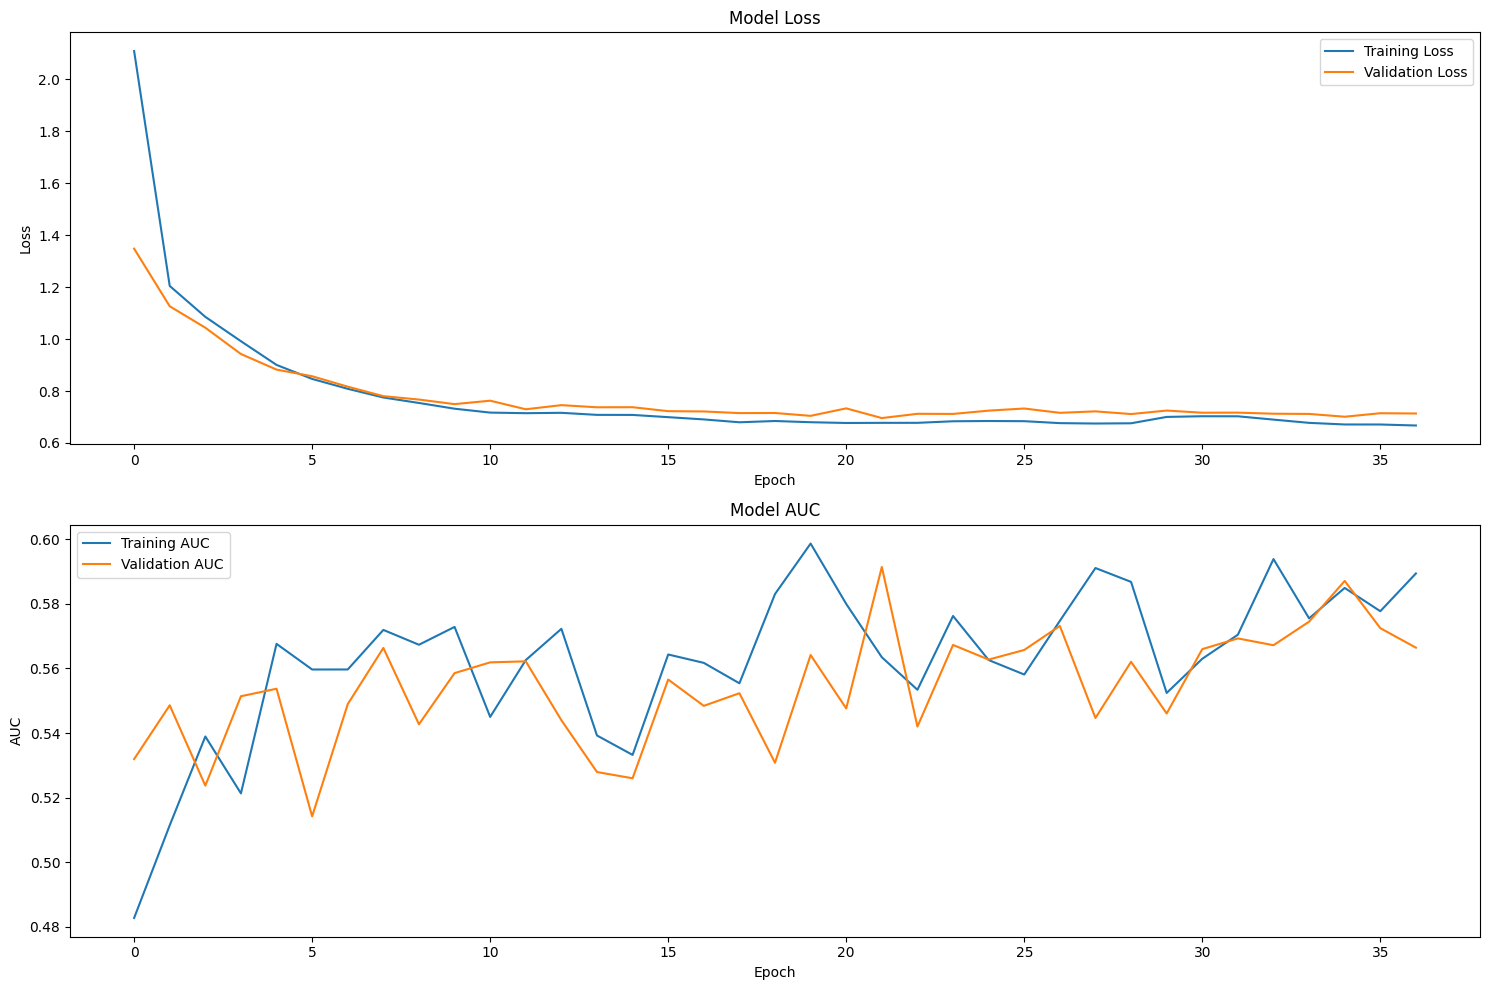

In [216]:
model.plot_training_history()

In [217]:
def evaluate_specific_match(data, filehash: str):
    game_data = data[data["filehash"] == filehash].copy()
    game_data_features = scaler.transform(game_data[FEATURES]).reshape(1, game_data.shape[0], len(FEATURES))
    
    predictions = model.predict(game_data_features)
    predictions = predictions.reshape(predictions.shape[1])
    
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(x=game_data["seconds"], y=predictions, color="blue")
    sns.lineplot(x=game_data["seconds"], y=game_data["winner"], color="red")
    sns.lineplot(x=game_data["seconds"], y=0.5, color="grey", alpha=0.5)
    plt.ylim(-0.01, 1.01)
    plt.xlim(0, game_data["seconds"].max())
    plt.xlabel("seconds")
    plt.ylabel("prediction")
    plt.show()
    return predictions

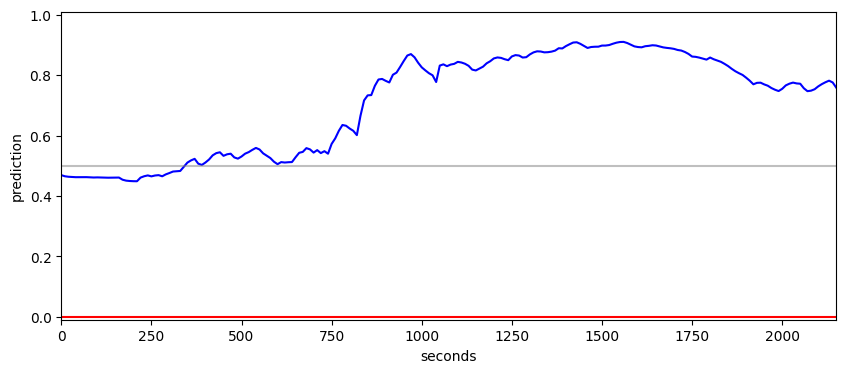

In [220]:
filehash = test_data["filehash"].unique()[1]
_ = evaluate_specific_match(test_data, filehash)

## Score Whole Batch

Text(0.5, 1.0, 'Brier Score: 0.207, ROC AUC: 0.741')

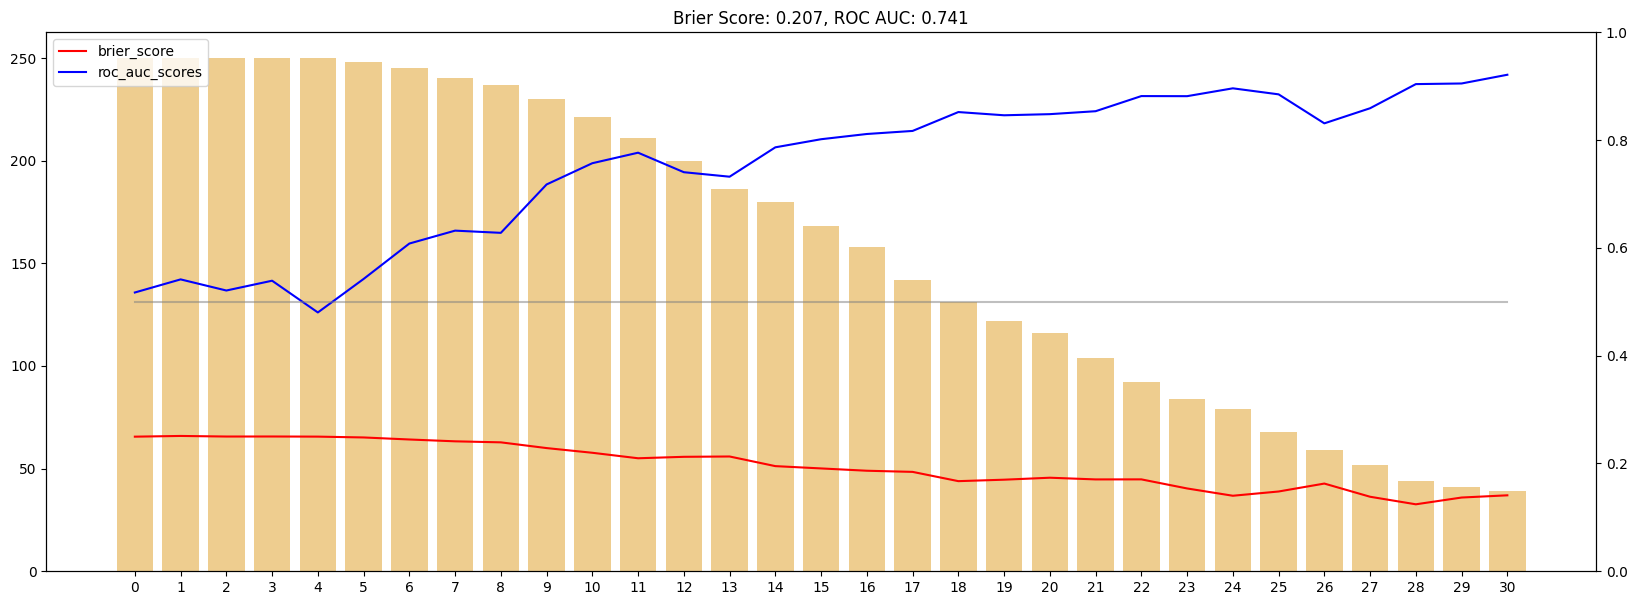

In [198]:
def score_batch(data: pd.DataFrame, id_column: str):
    groups = data.groupby(id_column)

    dataframes = []
    for group in groups:
        new_df = group[1].copy()
        features = scaler.transform(group[1][FEATURES]).reshape(1, group[1].shape[0], len(FEATURES))
        preds = model.predict(features)
        new_df["predictions"] = preds[0, :, 0]
        dataframes.append(new_df)

    return pd.concat(dataframes)

scored_train_batch = score_batch(train_data, "filehash")



def evaluate_for_specific_minute(data, minute):
    subset = data[data["seconds"] == minute*60]
    count = subset.shape[0]
    brier_score = brier_score_loss(subset["winner"], subset["predictions"])
    roc_auc = roc_auc_score(subset["winner"], subset["predictions"])
    return brier_score, roc_auc, count


brier_scores = []
roc_aucs = []
counts = []
overall_brier_score = brier_score_loss(scored_train_batch["winner"], scored_train_batch["predictions"])
overall_roc_auc = roc_auc_score(scored_train_batch["winner"], scored_train_batch["predictions"])
for i in range(0, 31):
    brier_score, roc_auc, count = evaluate_for_specific_minute(scored_train_batch, i)
    brier_scores.append(brier_score)
    roc_aucs.append(roc_auc)
    counts.append(count)

fig, ax = plt.subplots(figsize=(20, 7))
sns.barplot(x=np.arange(0, 31), y=counts, color="orange", alpha=0.5)
ax2 = ax.twinx()

sns.lineplot(x=np.arange(0, 31), y=brier_scores, label="brier_score", color="red")
sns.lineplot(x=np.arange(0, 31), y=roc_aucs, label="roc_auc_scores", color="blue")
sns.lineplot(x=np.arange(0, 31), y=0.5, color="grey", alpha=0.5)
ax2.set_ylim(0, 1)
plt.title(f"Brier Score: {np.round(overall_brier_score, 3)}, ROC AUC: {np.round(overall_roc_auc, 3)}")

/Users/nedwebster/Documents/python_projects/personal_projects/starcraft_predictor/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Text(0.5, 1.0, 'Brier Score: 0.203, ROC AUC: 0.761')

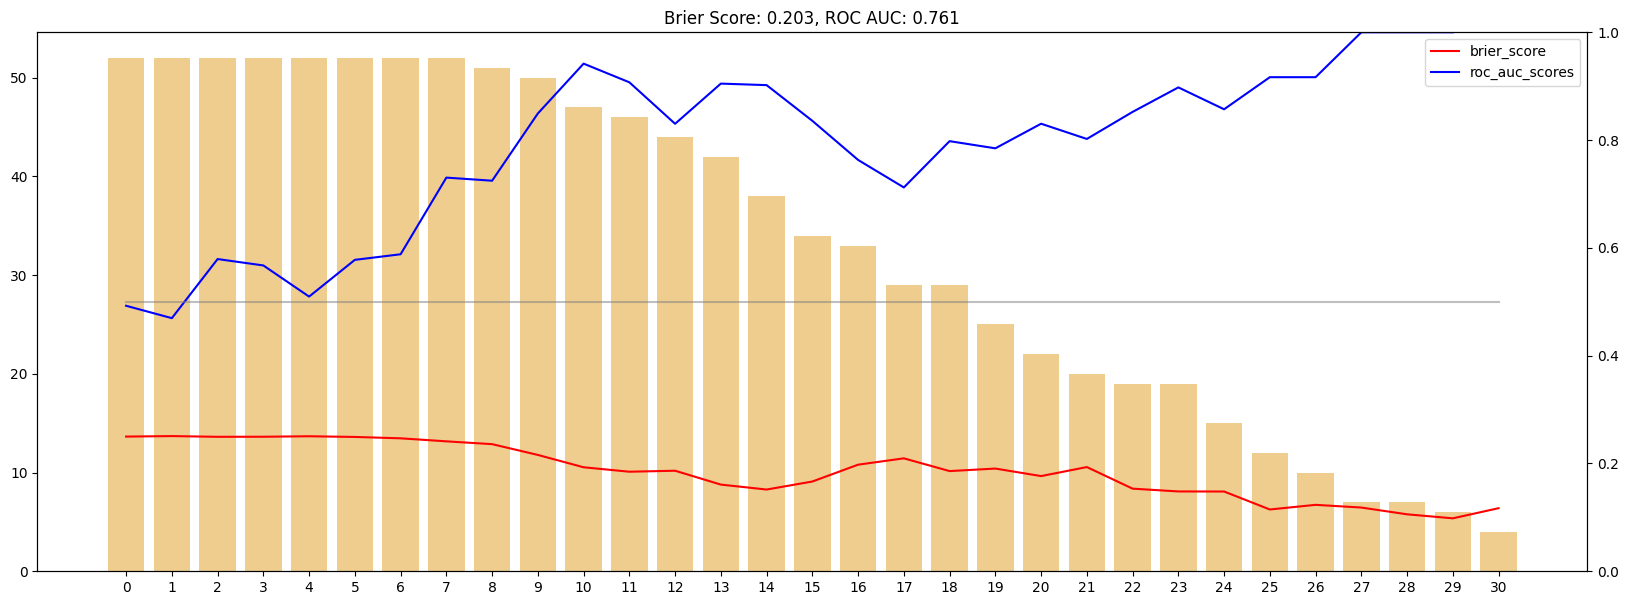

In [199]:
def score_batch(data: pd.DataFrame, id_column: str):
    groups = data.groupby(id_column)

    dataframes = []
    for group in groups:
        new_df = group[1].copy()
        features = scaler.transform(group[1][FEATURES]).reshape(1, group[1].shape[0], len(FEATURES))
        preds = model.predict(features)
        new_df["predictions"] = preds[0, :, 0]
        dataframes.append(new_df)

    return pd.concat(dataframes)

scored_test_batch = score_batch(test_data, "filehash")



def evaluate_for_specific_minute(data, minute):
    subset = data[data["seconds"] == minute*60]
    count = subset.shape[0]
    brier_score = brier_score_loss(subset["winner"], subset["predictions"])
    roc_auc = roc_auc_score(subset["winner"], subset["predictions"])
    return brier_score, roc_auc, count


brier_scores = []
roc_aucs = []
counts = []
overall_brier_score = brier_score_loss(scored_test_batch["winner"], scored_test_batch["predictions"])
overall_roc_auc = roc_auc_score(scored_test_batch["winner"], scored_test_batch["predictions"])
for i in range(0, 31):
    brier_score, roc_auc, count = evaluate_for_specific_minute(scored_test_batch, i)
    brier_scores.append(brier_score)
    roc_aucs.append(roc_auc)
    counts.append(count)

fig, ax = plt.subplots(figsize=(20, 7))
sns.barplot(x=np.arange(0, 31), y=counts, color="orange", alpha=0.5)
ax2 = ax.twinx()

sns.lineplot(x=np.arange(0, 31), y=brier_scores, label="brier_score", color="red")
sns.lineplot(x=np.arange(0, 31), y=roc_aucs, label="roc_auc_scores", color="blue")
sns.lineplot(x=np.arange(0, 31), y=0.5, color="grey", alpha=0.5)
ax2.set_ylim(0, 1)
plt.title(f"Brier Score: {np.round(overall_brier_score, 3)}, ROC AUC: {np.round(overall_roc_auc, 3)}")

In [200]:
tail_data = scored_test_batch.groupby("filehash").tail(1)

In [201]:
brier_score = brier_score_loss(tail_data["winner"], tail_data["predictions"])
roc_auc = roc_auc_score(tail_data["winner"], tail_data["predictions"])
print(f"Tail brier score: {brier_score}")
print(f"Tail roc_auc score: {roc_auc}")

Tail brier score: 0.062480303773536444
Tail roc_auc score: 0.994074074074074
